In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import shap
import matplotlib.pyplot as plt

c:\Users\sharm\OneDrive\Desktop\Churn-AI-System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df['Churn'].value_counts(normalize=True) * 100
df['TotalCharges'].head(10)
df['TotalCharges'].dtype

dtype('O')

In [7]:
df['TotalCharges'].dtype
(df['TotalCharges'] == " ").sum()

np.int64(11)

In [8]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

In [9]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [10]:
df = df.dropna()
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [11]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
df['Churn'].value_counts()
df['Churn'].unique()

array([0, 1])

In [12]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [13]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df = df.dropna()

In [14]:
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [15]:
df['Churn'] = df['Churn'].str.strip()

In [16]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})



In [17]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [18]:
df['Churn'] = df['Churn'].astype(str)
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [19]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [20]:
import pandas as pd
import numpy as np

In [21]:
df = pd.read_csv("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [22]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [23]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])
df = df.dropna()

In [24]:
df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})

C:\Users\sharm\AppData\Local\Temp\ipykernel_22184\372009398.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})


In [25]:
df = df.drop('customerID', axis=1)

In [26]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [27]:
X.dtypes.value_counts()

object     15
int64       2
float64     2
Name: count, dtype: int64

In [28]:
X = pd.get_dummies(X, drop_first=True)

In [29]:
X.shape

(7032, 30)

In [30]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [31]:
X_train.shape
X_test.shape

(1407, 30)

In [32]:
from imblearn.over_sampling import SMOTE

In [33]:
X_train.dtypes.value_counts()

bool       26
int64       2
float64     2
Name: count, dtype: int64

In [34]:
X_train.isnull().sum().sum()

np.int64(0)

In [35]:
X_train = X_train.astype(float)
X_test = X_test.astype(float)

In [36]:
X_train.isnull().sum().sum()
y_train.dtype

dtype('int64')

In [37]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)
y_train.dtype

dtype('int64')

In [38]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [39]:
y_train_sm.value_counts()

Churn
0    4130
1    4130
Name: count, dtype: int64

In [40]:
from sklearn.linear_model import LogisticRegression

In [41]:
log_model = LogisticRegression(max_iter=1000)

In [42]:
log_model.fit(X_train_sm, y_train_sm)

c:\Users\sharm\OneDrive\Desktop\Churn-AI-System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [43]:
y_pred = log_model.predict(X_test)

In [44]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

In [45]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))

Accuracy: 0.7313432835820896
Precision: 0.49658703071672355
Recall: 0.7780748663101604
F1 Score: 0.60625
ROC-AUC: 0.7462494370272971


In [46]:
from sklearn.ensemble import RandomForestClassifier

In [47]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [48]:
rf_model.fit(X_train_sm, y_train_sm)
y_pred_rf = rf_model.predict(X_test)

In [49]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_pred_rf))

Accuracy: 0.7860696517412935
Precision: 0.6130030959752322
Recall: 0.5294117647058824
F1 Score: 0.5681492109038737
ROC-AUC: 0.7042024941632026


In [50]:
y_prob_log = log_model.predict_proba(X_test)[:, 1]

In [51]:
roc_auc_score(y_test, y_prob_log)

0.8347125086063643

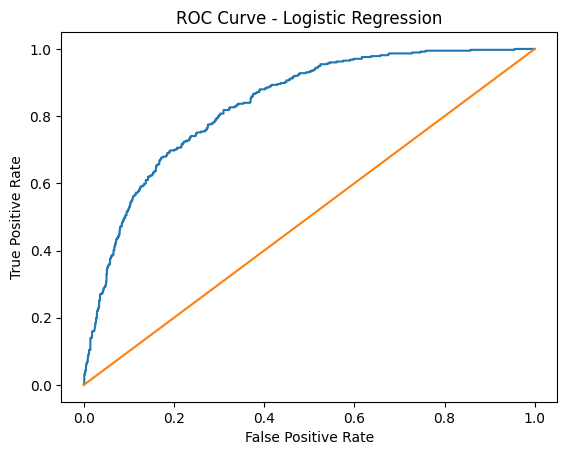

In [52]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [53]:
y_pred_04 = (y_prob_log > 0.4).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred_04))
print("Precision:", precision_score(y_test, y_pred_04))
print("Recall:", recall_score(y_test, y_pred_04))
print("F1 Score:", f1_score(y_test, y_pred_04))

Accuracy: 0.6908315565031983
Precision: 0.45573294629898403
Recall: 0.839572192513369
F1 Score: 0.5907808090310442


In [54]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})

feature_importance['AbsCoefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='AbsCoefficient', ascending=False)

feature_importance.head(10)

,Feature,Coefficient,AbsCoefficient
25,Contract_Two year,-1.471903,1.471903
24,Contract_One year,-0.823994,0.823994
19,TechSupport_Yes,-0.596517,0.596517
8,MultipleLines_No phone service,0.571608,0.571608
13,OnlineSecurity_Yes,-0.571243,0.571243
28,PaymentMethod_Electronic check,0.439860,0.439860
10,InternetService_Fiber optic,0.424359,0.424359
7,PhoneService_Yes,-0.354138,0.354138
15,OnlineBackup_Yes,-0.346314,0.346314
26,PaperlessBilling_Yes,0.336351,0.336351


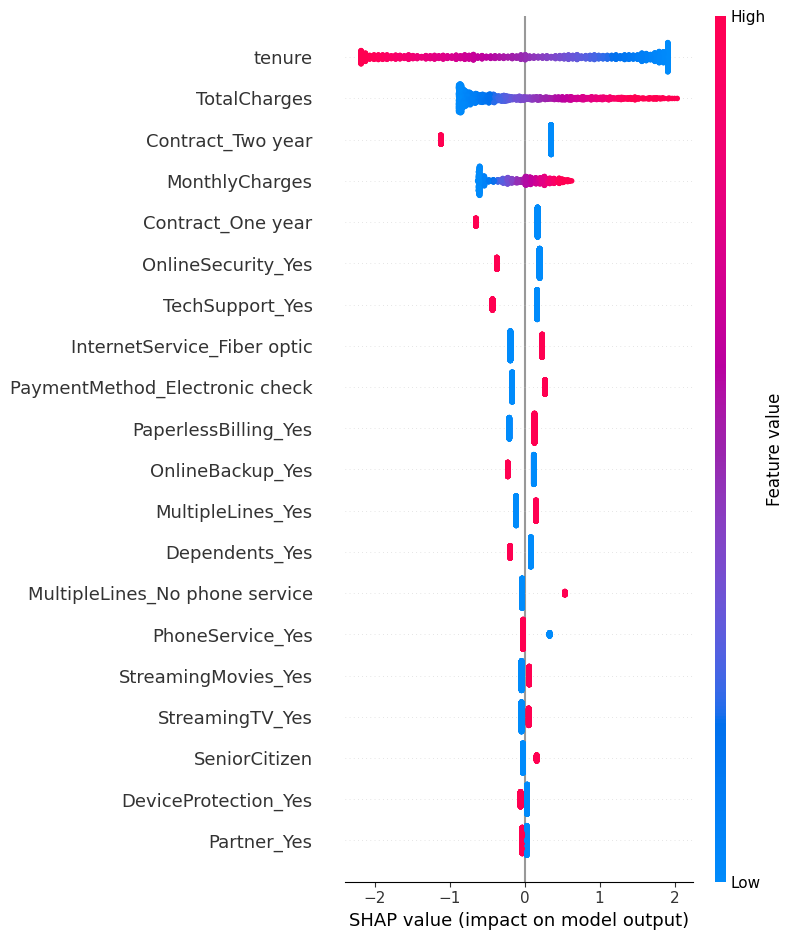

In [55]:
import shap

explainer = shap.LinearExplainer(log_model, X_train)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

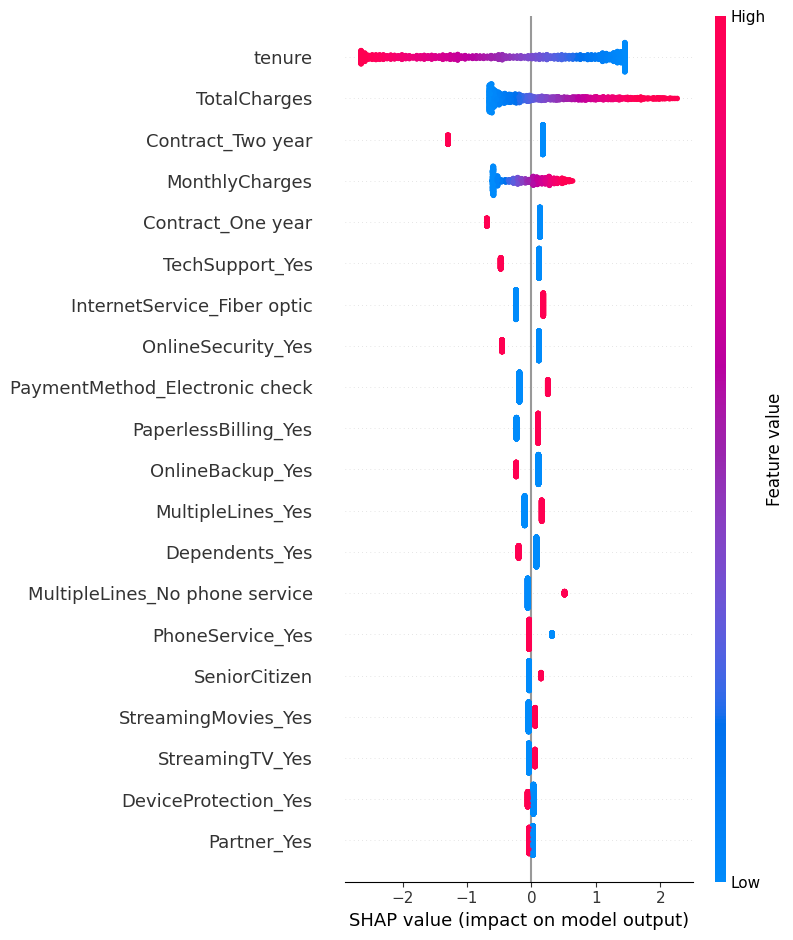

In [56]:
explainer = shap.LinearExplainer(log_model, X_train_sm)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test)

In [57]:
shap.initjs()
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_test.iloc[0]
)

In [58]:
shap.force_plot(
    explainer.expected_value,
    shap_values[10],
    X_test.iloc[10]
)

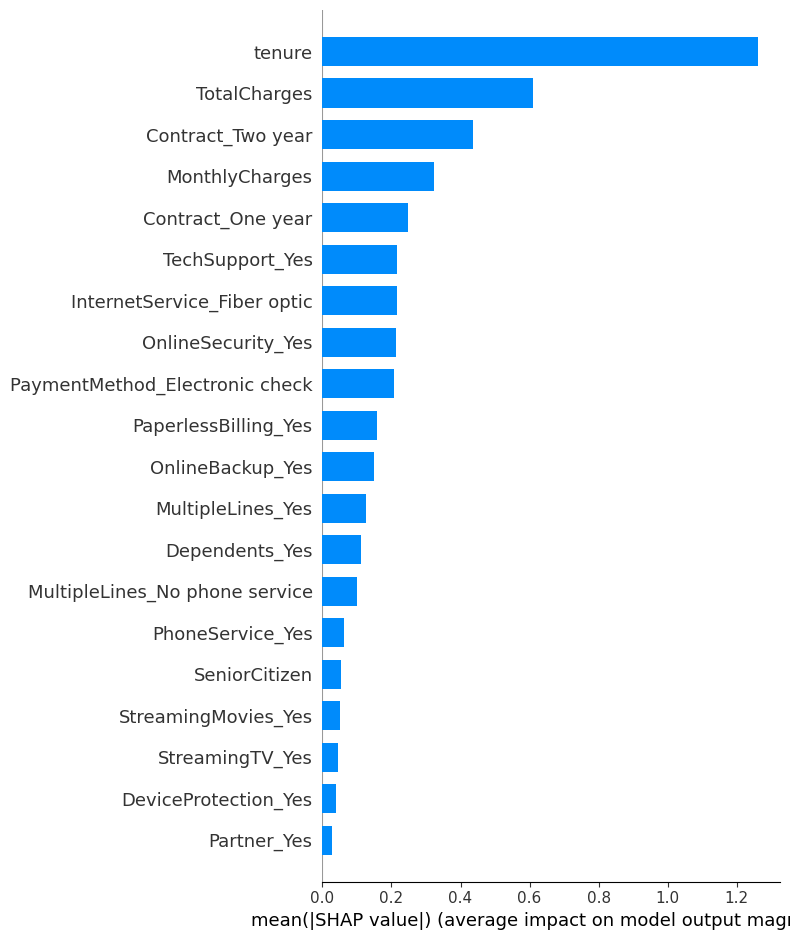

In [59]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [60]:
churn_prob = log_model.predict_proba(X_test)[:,1]

In [61]:
import pandas as pd

risk_df = pd.DataFrame({
    "Churn_Probability": churn_prob
})
risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[0,0.3,0.7,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)
risk_df.head()


,Churn_Probability,Risk_Level
0,0.039186,Low Risk
1,0.786411,High Risk
2,0.009824,Low Risk
3,0.380699,Medium Risk
4,0.248970,Low Risk


In [62]:
import pickle

pickle.dump(log_model, open("churn_model.pkl", "wb"))

In [63]:
from sklearn.pipeline import Pipeline
import pickle

pipeline = Pipeline([
    ("model", log_model)
])

pickle.dump(pipeline, open("churn_pipeline.pkl","wb"))

In [64]:
churn_prob = log_model.predict_proba(X_test)[:,1]

In [65]:
import pandas as pd

risk_df = pd.DataFrame({
    "Churn_Probability": churn_prob
})
risk_df["Risk_Level"] = pd.cut(
    risk_df["Churn_Probability"],
    bins=[0,0.3,0.7,1],
    labels=["Low Risk","Medium Risk","High Risk"]
)

In [66]:
risk_df["Risk_Level"].value_counts()

Risk_Level
Low Risk       594
Medium Risk    437
High Risk      376
Name: count, dtype: int64

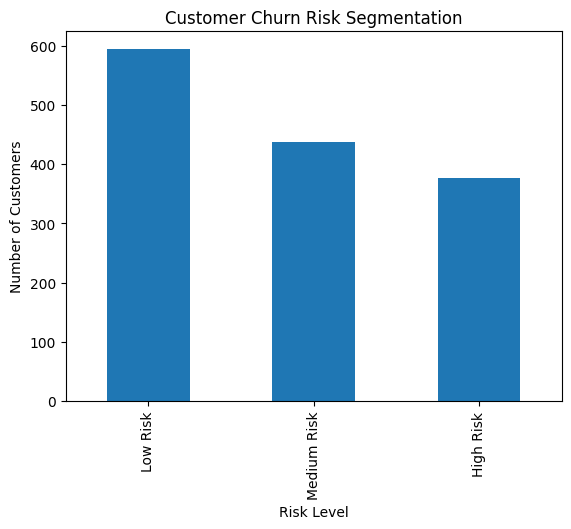

In [67]:
import matplotlib.pyplot as plt

risk_df["Risk_Level"].value_counts().plot(kind="bar")

plt.title("Customer Churn Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")
plt.show()

In [68]:
import numpy as np
import pandas as pd

feature_importance = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": feature_importance
})

importance_df = importance_df.sort_values(by="Importance", ascending=False)

importance_df.head(10)

,Feature,Importance
1,tenure,1.261926
3,TotalCharges,0.608709
25,Contract_Two year,0.436612
2,MonthlyCharges,0.322013
24,Contract_One year,0.247539
19,TechSupport_Yes,0.216581
10,InternetService_Fiber optic,0.215884
13,OnlineSecurity_Yes,0.212396
28,PaymentMethod_Electronic check,0.208329
26,PaperlessBilling_Yes,0.157648


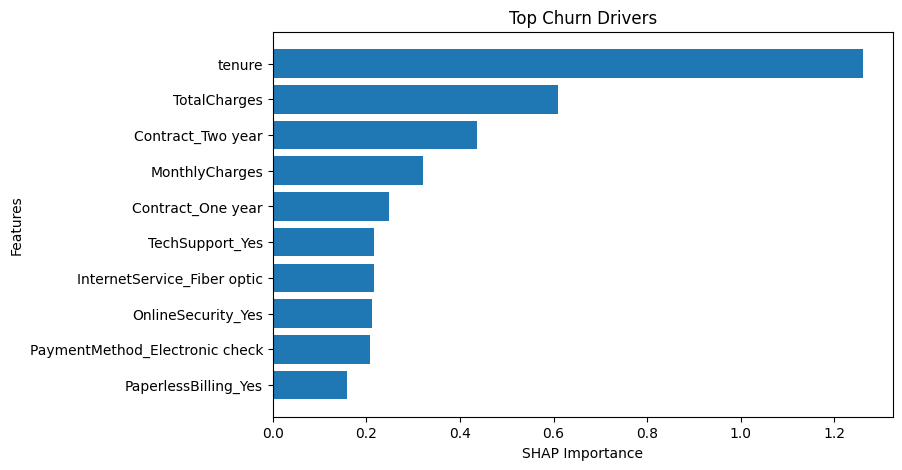

In [69]:
import matplotlib.pyplot as plt

top_features = importance_df.head(10)

plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()

plt.title("Top Churn Drivers")
plt.xlabel("SHAP Importance")
plt.ylabel("Features")

plt.show()


In [70]:
def retention_strategy(feature):

    if "MonthlyCharges" in feature:
        return "Offer discounted pricing or loyalty plan"

    elif "tenure" in feature:
        return "Introduce long-term contract incentives"

    elif "Contract" in feature:
        return "Encourage yearly contract upgrade"

    else:
        return "Monitor customer engagement"


importance_df["Retention_Action"] = importance_df["Feature"].apply(retention_strategy)

importance_df.head(10)

,Feature,Importance,Retention_Action
1,tenure,1.261926,Introduce long-term contract incentives
3,TotalCharges,0.608709,Monitor customer engagement
25,Contract_Two year,0.436612,Encourage yearly contract upgrade
2,MonthlyCharges,0.322013,Offer discounted pricing or loyalty plan
24,Contract_One year,0.247539,Encourage yearly contract upgrade
19,TechSupport_Yes,0.216581,Monitor customer engagement
10,InternetService_Fiber optic,0.215884,Monitor customer engagement
13,OnlineSecurity_Yes,0.212396,Monitor customer engagement
28,PaymentMethod_Electronic check,0.208329,Monitor customer engagement
26,PaperlessBilling_Yes,0.157648,Monitor customer engagement


In [71]:
churn_prob = log_model.predict_proba(X_test)[:,1]

In [72]:
customer_risk_df = X_test.copy()

customer_risk_df["Churn_Probability"] = churn_prob

In [73]:
high_risk_customers = customer_risk_df[
    customer_risk_df["Churn_Probability"] > 0.7
]

high_risk_customers.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability
619,0.0,7.0,78.55,522.95,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.786411
445,0.0,60.0,105.90,6396.45,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.753922
1346,0.0,14.0,87.25,1258.60,0.0,1.0,1.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.848315
4283,1.0,4.0,70.20,280.35,1.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.875062
6128,0.0,14.0,78.10,1122.40,0.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.840409


In [74]:
high_risk_customers = high_risk_customers.sort_values(
    by="Churn_Probability",
    ascending=False
)

high_risk_customers.head(10)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability
3159,1.0,3.0,94.85,335.75,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.945518
3380,1.0,1.0,95.10,95.10,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.944387
3727,0.0,3.0,96.60,291.90,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.935052
4585,1.0,1.0,85.05,85.05,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.934388
2797,0.0,3.0,100.95,329.95,1.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.934294
2631,1.0,7.0,99.25,665.45,1.0,1.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.933463
933,1.0,4.0,84.60,360.10,0.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.928924
2516,1.0,16.0,96.40,1581.20,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.926494
582,1.0,4.0,89.20,346.20,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.926061
6839,0.0,11.0,100.75,1129.75,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.920630


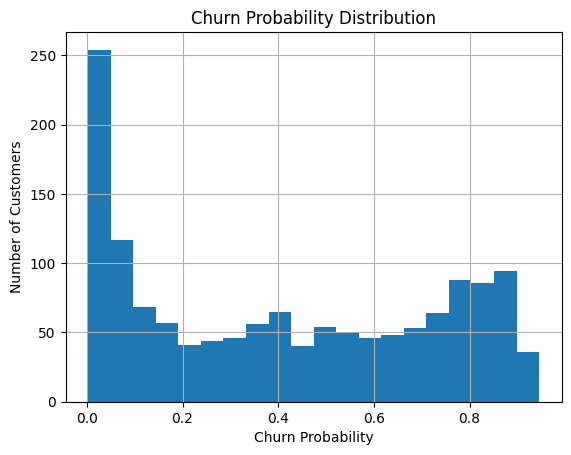

In [75]:
import matplotlib.pyplot as plt

customer_risk_df["Churn_Probability"].hist(bins=20)

plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

In [76]:
customer_risk_df["CLV"] = customer_risk_df["MonthlyCharges"] * customer_risk_df["tenure"]

In [77]:
customer_risk_df["Customer_Value"] = pd.cut(
    customer_risk_df["CLV"],
    bins=[0,1000,3000,10000],
    labels=["Low Value","Medium Value","High Value"]
)

In [78]:
customer_risk_df[[
    "Churn_Probability",
    "Customer_Value",
    "CLV"
]].head()

,Churn_Probability,Customer_Value,CLV
974,0.039186,High Value,4481.05
619,0.786411,Low Value,549.85
4289,0.009824,Medium Value,1085.40
3721,0.380699,Low Value,41.30
4533,0.248970,High Value,7465.65


In [79]:
critical_customers = customer_risk_df[
    (customer_risk_df["Churn_Probability"] > 0.7) &
    (customer_risk_df["Customer_Value"] == "High Value")
]

critical_customers.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Probability,CLV,Customer_Value
445,0.0,60.0,105.90,6396.45,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.753922,6354.00,High Value
3910,0.0,47.0,106.40,5127.95,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.809645,5000.80,High Value
3463,0.0,37.0,91.15,3369.25,1.0,0.0,0.0,1.0,0.0,1.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.733380,3372.55,High Value
2474,0.0,47.0,106.35,4849.10,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.794624,4998.45,High Value
3251,1.0,37.0,106.75,4056.75,0.0,0.0,0.0,1.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.717041,3949.75,High Value


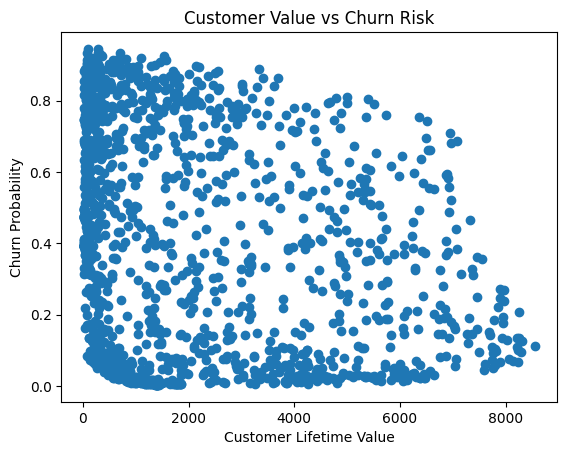

In [80]:
import matplotlib.pyplot as plt

plt.scatter(
    customer_risk_df["CLV"],
    customer_risk_df["Churn_Probability"]
)

plt.xlabel("Customer Lifetime Value")
plt.ylabel("Churn Probability")
plt.title("Customer Value vs Churn Risk")

plt.show()

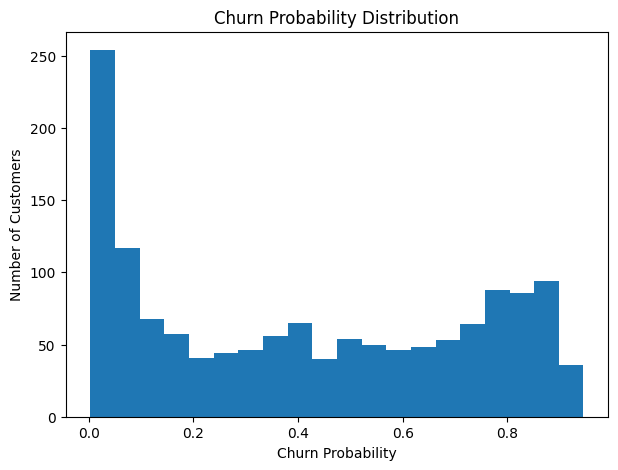

In [81]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.hist(customer_risk_df["Churn_Probability"], bins=20)

plt.title("Churn Probability Distribution")
plt.xlabel("Churn Probability")
plt.ylabel("Number of Customers")

plt.show()

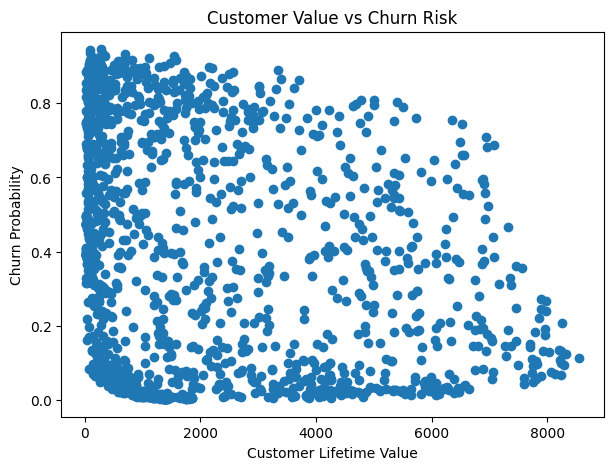

In [82]:
plt.figure(figsize=(7,5))

plt.scatter(
    customer_risk_df["CLV"],
    customer_risk_df["Churn_Probability"]
)

plt.xlabel("Customer Lifetime Value")
plt.ylabel("Churn Probability")
plt.title("Customer Value vs Churn Risk")

plt.show()

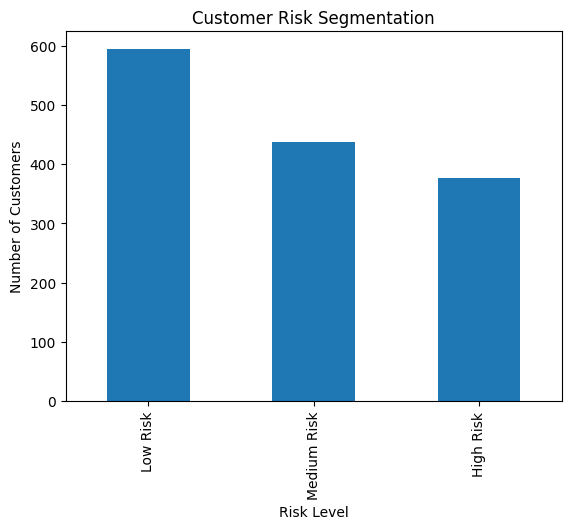

In [83]:
risk_counts = risk_df["Risk_Level"].value_counts()

risk_counts.plot(kind="bar")

plt.title("Customer Risk Segmentation")
plt.xlabel("Risk Level")
plt.ylabel("Number of Customers")

plt.show()

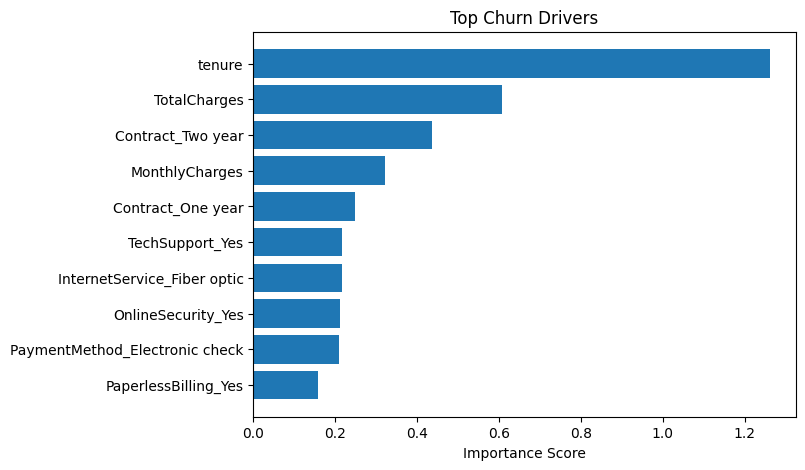

In [84]:
top_features = importance_df.head(10)

plt.figure(figsize=(7,5))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.gca().invert_yaxis()

plt.title("Top Churn Drivers")
plt.xlabel("Importance Score")

plt.show()

In [85]:
revenue_at_risk = critical_customers["CLV"].sum()

print("Total Revenue at Risk:", revenue_at_risk)

Total Revenue at Risk: 173488.95


In [86]:
import pickle

pickle.dump(log_model, open("churn_model.pkl", "wb"))

In [87]:
from sklearn.pipeline import Pipeline
import pickle

In [88]:
pipeline = Pipeline([
    ("model", log_model)
])
pickle.dump(pipeline, open("churn_pipeline.pkl", "wb"))

In [89]:
len(X_train.columns)

30

In [90]:
X_train.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [91]:
X_train.columns.tolist()

['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_No phone service',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_No internet service',
 'OnlineSecurity_Yes',
 'OnlineBackup_No internet service',
 'OnlineBackup_Yes',
 'DeviceProtection_No internet service',
 'DeviceProtection_Yes',
 'TechSupport_No internet service',
 'TechSupport_Yes',
 'StreamingTV_No internet service',
 'StreamingTV_Yes',
 'StreamingMovies_No internet service',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [92]:
import pickle

pickle.dump(X_train.columns.tolist(), open("feature_columns.pkl","wb"))

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, precision_score, recall_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import pandas as pd

In [94]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "XGBoost": xgb.XGBClassifier()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    precision = precision_score(y_test, preds)
    recall = recall_score(y_test, preds)
    f1 = f1_score(y_test, preds)

    results[name] = f1

    print(name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("-----------")
    

c:\Users\sharm\OneDrive\Desktop\Churn-AI-System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression
Precision: 0.6456456456456456
Recall: 0.5748663101604278
F1 Score: 0.6082036775106082
-----------
Random Forest
Precision: 0.6161616161616161
Recall: 0.4893048128342246
F1 Score: 0.5454545454545454
-----------
XGBoost
Precision: 0.5890804597701149
Recall: 0.5481283422459893
F1 Score: 0.5678670360110804
-----------


In [95]:
import pandas as pd

comparison_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "F1 Score"]
)

comparison_df

,Model,F1 Score
0,Logistic Regression,0.608204
1,Random Forest,0.545455
2,XGBoost,0.567867


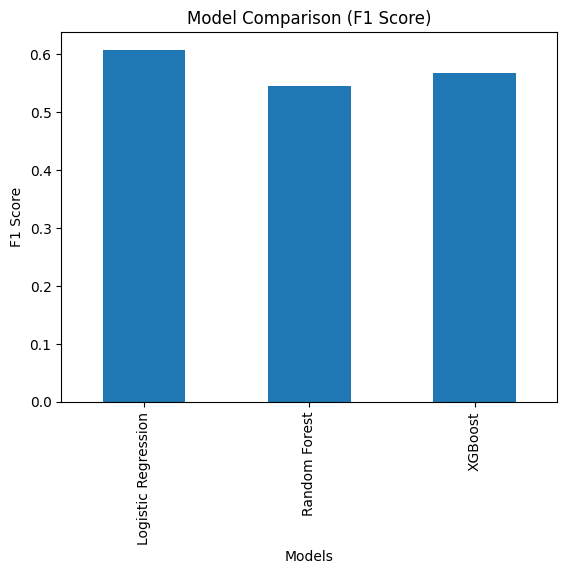

In [96]:
import matplotlib.pyplot as plt

comparison_df.set_index("Model")["F1 Score"].plot(kind="bar")

plt.title("Model Comparison (F1 Score)")
plt.ylabel("F1 Score")
plt.xlabel("Models")

plt.show()

In [97]:
best_model_name = max(results, key=results.get)

print("Best Model:", best_model_name)

Best Model: Logistic Regression


In [98]:
import joblib

best_model = models[best_model_name]

best_model.fit(X_train, y_train)

joblib.dump(best_model, "churn_model.pkl")

c:\Users\sharm\OneDrive\Desktop\Churn-AI-System\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['churn_model.pkl']

In [100]:
xgb_model = xgb.XGBClassifier()

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [101]:
importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
10,InternetService_Fiber optic,0.428605
25,Contract_Two year,0.183020
24,Contract_One year,0.095892
11,InternetService_No,0.053473
23,StreamingMovies_Yes,0.023632
1,tenure,0.023448
13,OnlineSecurity_Yes,0.015021
28,PaymentMethod_Electronic check,0.014857
9,MultipleLines_Yes,0.013778
21,StreamingTV_Yes,0.013468


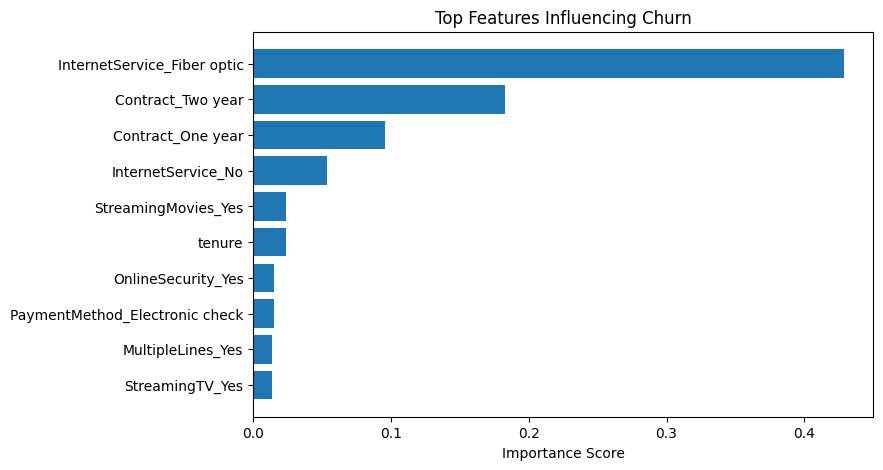

In [102]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(top_features["Feature"], top_features["Importance"])

plt.title("Top Features Influencing Churn")
plt.xlabel("Importance Score")

plt.gca().invert_yaxis()

plt.show()

In [104]:
import joblib

joblib.dump(xgb_model, "churn_model.pkl")

['churn_model.pkl']